In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from SharedModules import input_dir, output_dir, model_dir
from statsmodels.api import Logit, add_constant
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score 

warnings.filterwarnings("ignore")

_train = pd.read_csv(input_dir + "train.csv", index_col=0)
_test = pd.read_csv(input_dir + "test.csv", index_col=0)

target = "Heart Disease"

cv = KFold(n_splits=10, shuffle=True, random_state=42)

X = _train.drop(target, axis=1)
y = _train[target].map({"Absence":0, "Presence": 1})
X_test = _test

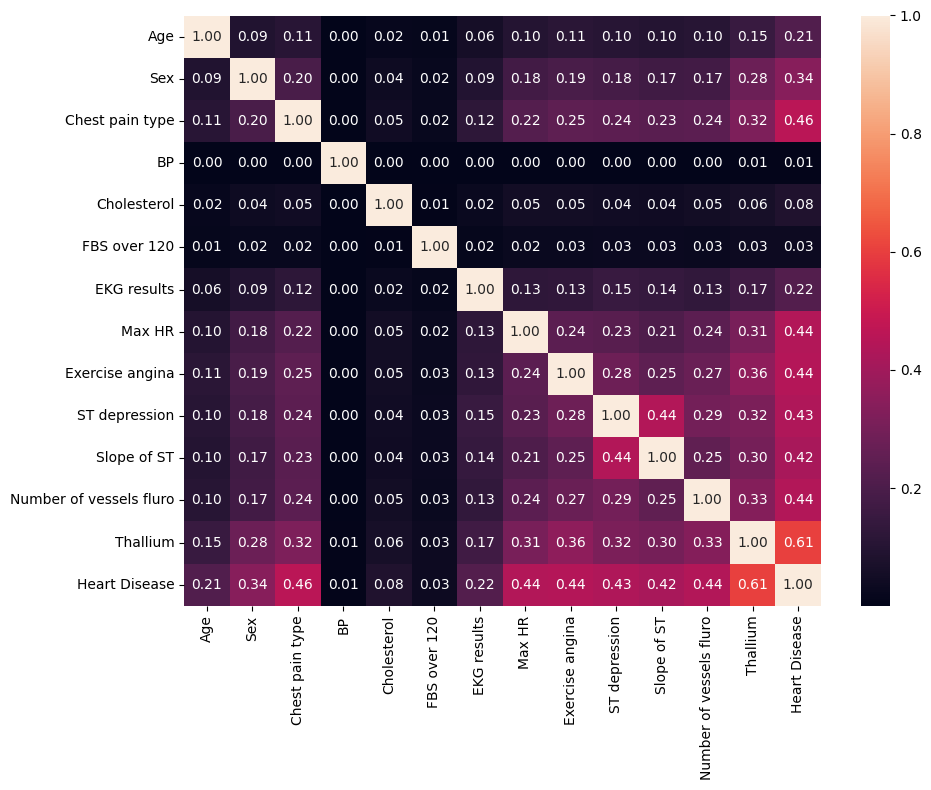

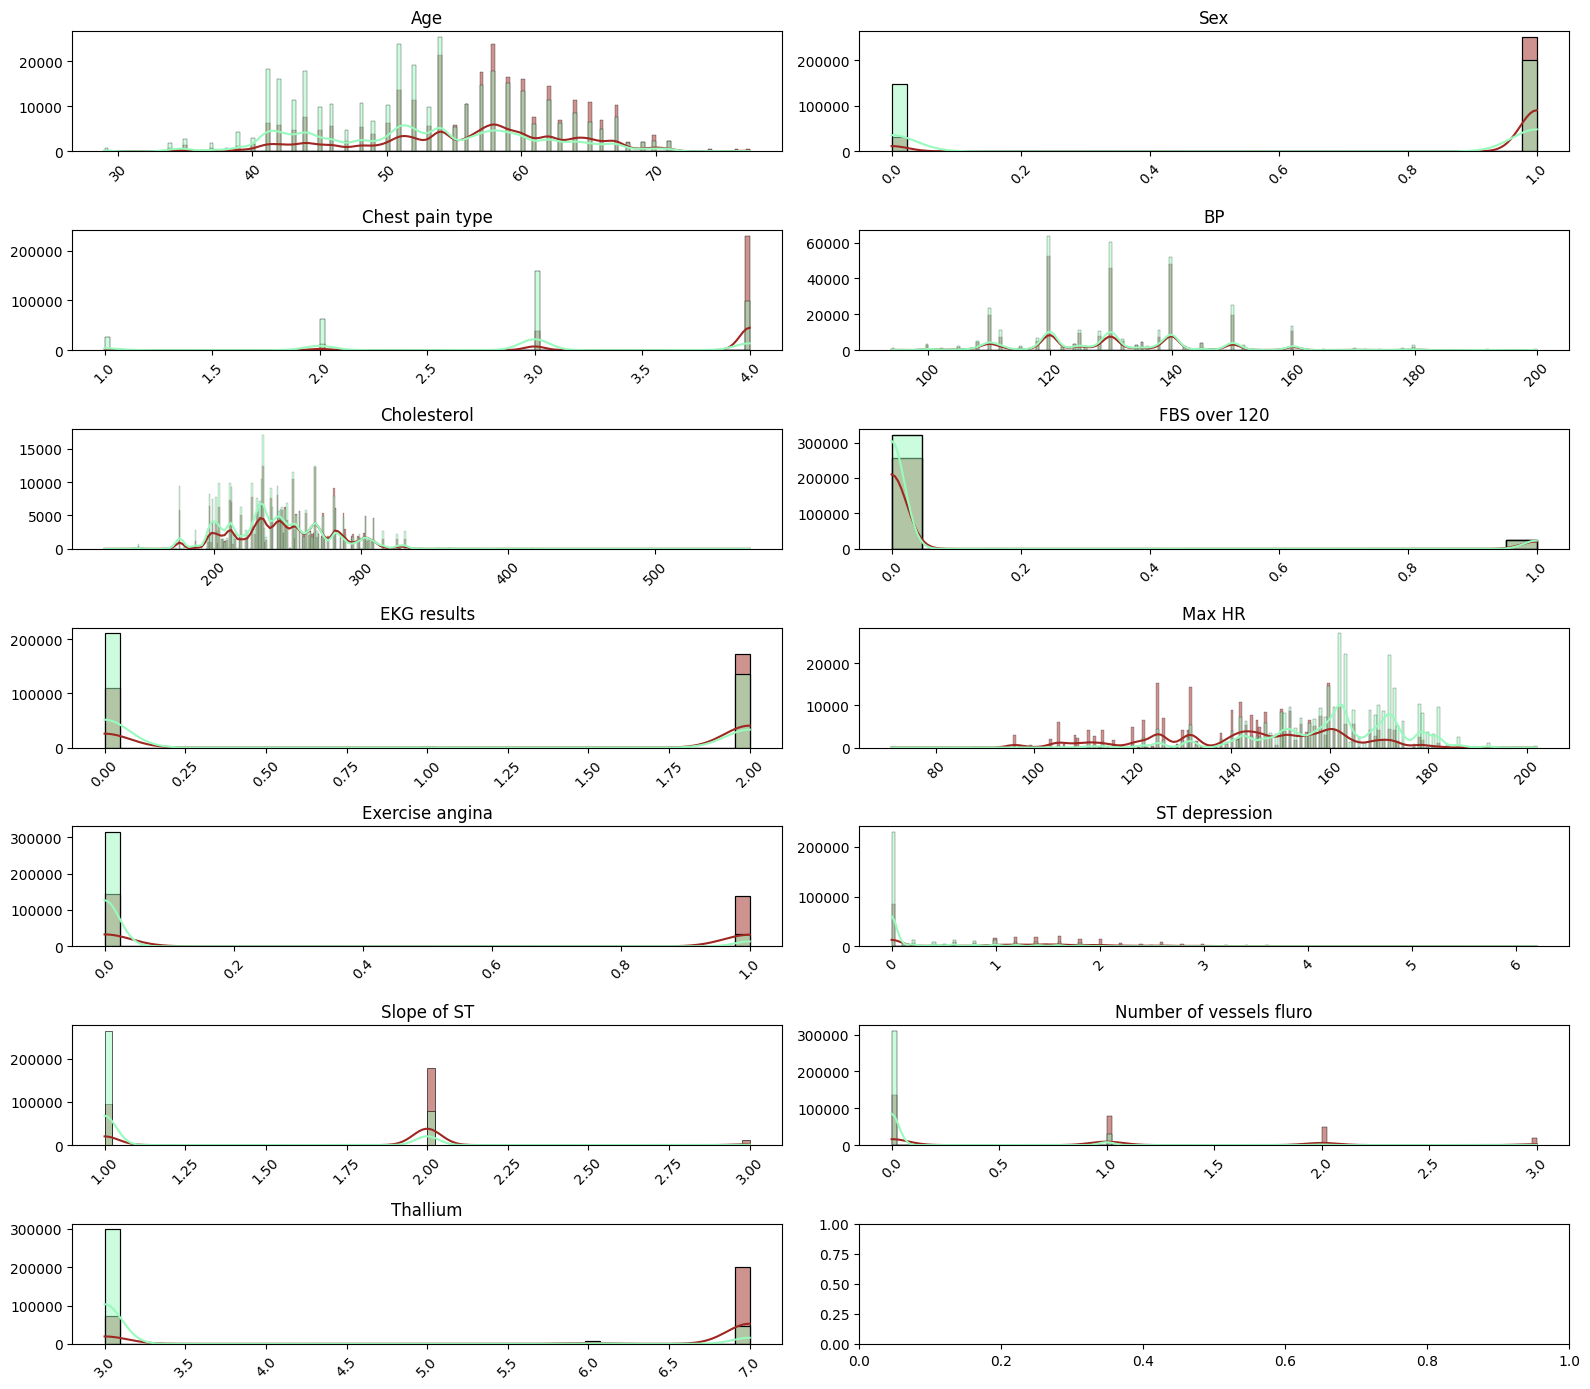

In [2]:
corr = pd.concat([X, y], axis=1).corr().abs()

fig = plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, fmt=".2f", annot=True)
plt.tight_layout()
plt.show()

columns = 2
rows = -(len(X.columns) // -columns)

fig, ax = plt.subplots(rows, columns, figsize=(columns * 8, rows * 2))

for i, col in enumerate(X):
  axes = ax[i//columns, i%columns]
  sns.histplot(data=_train, x=col, hue=target, palette=["#98fabc", "#9e2721"], kde=True, ax=axes)
  axes.set_title(col)
  axes.set(xlabel=None, ylabel=None)
  axes.tick_params(axis="x", rotation=45)
  axes.legend().remove()

plt.tight_layout()
plt.show()

In [3]:
oof = np.zeros(len(X))
oof_scores = []

for fold, (idx_tr, idx_val) in enumerate(cv.split(X, y)):
    X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_tr], y.iloc[idx_val]

    model = Logit(y_tr, add_constant(X_tr)).fit(disp=False)
    y_pred = model.predict(add_constant(X_val))
    score = roc_auc_score(y_val, y_pred)

    oof[idx_val] = y_pred
    oof_scores.append(score)

    print(f"fold {fold + 1} score: {score:.4f}")

print(f"Average Score: {np.mean(oof_scores): .4f}")

df_oof = pd.DataFrame(data=oof, index=X.index, columns=["StatsModels"])
df_oof.to_csv(model_dir + "statsmodels/oof.csv")

fold 1 score: 0.9508
fold 2 score: 0.9496
fold 3 score: 0.9506
fold 4 score: 0.9510
fold 5 score: 0.9495
fold 6 score: 0.9526
fold 7 score: 0.9499
fold 8 score: 0.9497
fold 9 score: 0.9508
fold 10 score: 0.9504
Average Score:  0.9505


In [4]:
model = Logit(y, add_constant(X)).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.281743
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          Heart Disease   No. Observations:               630000
Model:                          Logit   Df Residuals:                   629986
Method:                           MLE   Df Model:                           13
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                  0.5904
Time:                        22:33:15   Log-Likelihood:            -1.7750e+05
converged:                       True   LL-Null:                   -4.3331e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -5.6101      0.074    -75.988      0.000      -5.755   

In [ ]:
sub = model.predict(add_constant(X_test))
sub.rename("StatsModels").to_csv(output_dir + "submission_statsmodels.csv")